# 12 · Carry Trade: FX, Crash Risk, and Why Sharpe Ratios Lie

*Module 3 — Quantitative Strategies*

A strategy that earns money steadily for years and then gives much of it back in days. Understanding why this shape recurs across markets is one of the most important lessons in all of quantitative finance.

## 1. Motivation

If you could borrow for free in one currency and lend at a much higher rate in another, wouldn't you? Millions of investors effectively do exactly this, every day, through the foreign exchange **carry trade** — and on average, over long stretches, it works. Then, every so often, it doesn't: carry trades have a well-documented history of giving back years of steady gains in a matter of days, exactly when global markets are already under stress. Understanding *why* carry earns a premium at all, and why that premium comes bundled with this specific kind of risk, is the point of this notebook.

## 2. Intuition

**Carry** is the return you earn just from *holding* an asset, independent of any price appreciation. In FX, it is the interest-rate differential between two countries: borrow in a low-yield currency, convert into and hold a high-yield currency, and pocket the difference in rates. A textbook theory — **uncovered interest rate parity (UIP)** — says this should not work on average: the high-yield currency "should" be expected to depreciate by exactly enough to offset its rate advantage, leaving no free lunch. Empirically, it depreciates by *less* than that on average (a well-documented anomaly known as the forward premium puzzle), so carry earns a real, persistent premium over time.

That premium is not free money — it is compensation for a specific, recurring danger. Carry-funding currencies (historically, low-yield currencies like the Japanese yen) tend to strengthen sharply exactly when global risk appetite collapses, because that is precisely when investors everywhere rush to unwind the same leveraged bet simultaneously. The strategy's return profile has a memorable, informal description shared across many "return-harvesting" strategies with this shape: **picking up nickels in front of a steamroller.** We will see this shape directly in the data below, and — just as importantly — see how a simple Sharpe ratio can completely hide it.

## 3. Theory

### 3.1 Uncovered interest rate parity and the forward premium puzzle

UIP states that the expected change in the exchange rate should equal the interest-rate differential:

$$
\mathbb E_t[\Delta s_{t+1}] = i_{domestic} - i_{foreign} ,
$$

where $s_t$ is the exchange rate (domestic currency per unit of foreign currency). If the foreign rate is higher, the foreign currency should be expected to *depreciate* by just enough to equalize expected returns across the two currencies — no free lunch. Fama (1984) was among the first to show this fails empirically in a specific, striking way: regressions of future exchange-rate changes on the current interest-rate differential often produce the *opposite sign* UIP predicts. High-interest-rate currencies do not reliably depreciate enough (and sometimes even appreciate), leaving a real average return to a naive strategy that simply buys high-yield currencies and funds the position in low-yield ones.

### 3.2 Carry return, decomposed

For a strategy that borrows in low-yield currency $L$ and invests in high-yield currency $H$, the return over one period is approximately

$$
R_{carry} \approx \underbrace{(i_H - i_L)}_{\text{interest earned}} \;+\; \underbrace{\Delta s}_{\text{FX move of } H \text{ vs. } L} ,
$$

where $\Delta s < 0$ means $H$ depreciated against $L$ over the period (subtracting from the carry income earned) and $\Delta s>0$ means it appreciated (adding to it). The forward premium puzzle says the first term dominates *on average*; crash risk means the second term occasionally dominates, violently, in the other direction.

### 3.3 Crash risk and skewness

Carry-trade returns are typically **negatively skewed**, with a heavier-than-normal left tail: mostly small, steady gains, punctuated by rare, large losses. This is invisible to a Sharpe ratio, which only looks at mean and standard deviation — two strategies with an *identical* Sharpe ratio can have completely different tail-risk profiles, and Section 5 makes this concrete side by side.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(31)

## 4. Implementation

### 4.1 Simulating a basket of carry trades with correlated crash risk

We build five simplified currency-pair carry positions with different interest-rate differentials. Each pair earns most of its rate differential as expected return (consistent with the forward premium puzzle), plus ordinary daily noise -- and, on rare, *shared* days across all five pairs simultaneously, a correlated "risk-off" crash, scaled larger for the higher-yielding, riskier pairs. This shared trigger is the key modeling choice: it is what makes carry crashes a *systemic* event across many pairs at once, not an idiosyncratic accident in just one.

In [2]:
pairs = ['AUDJPY', 'NZDUSD', 'MXNJPY', 'TRYJPY', 'ZARJPY']
rate_diff = np.array([0.020, 0.025, 0.035, 0.055, 0.045])    # illustrative annual interest-rate differentials
daily_vol = np.array([0.0058, 0.0062, 0.0070, 0.0100, 0.0088])
crash_severity = np.array([0.014, 0.016, 0.020, 0.035, 0.028])  # higher-yielding pairs crash harder
uip_offset_fraction = 0.05    # only a small fraction of the differential is offset by expected FX depreciation
p_crash = 0.0013              # roughly one shared crash event every ~3 years, across the whole basket

n_days = 252 * 10
daily_carry_drift = (rate_diff / 252) * (1 - uip_offset_fraction)

R = np.zeros((n_days, len(pairs)))
crash_days = rng.random(n_days) < p_crash
for t in range(n_days):
    R[t] = daily_carry_drift + rng.normal(0, daily_vol)
    if crash_days[t]:
        R[t] -= crash_severity * (1 + 0.5 * rng.random(len(pairs)))   # shared trigger, some idiosyncratic severity

R = pd.DataFrame(R, columns=pairs, index=pd.bdate_range('2016-01-04', periods=n_days))
basket = R.mean(axis=1)   # equal-weighted carry basket
print(f"Simulated {n_days} trading days, with {crash_days.sum()} shared crash days.")

Simulated 2520 trading days, with 4 shared crash days.


### 4.2 A "safe" comparison strategy with the SAME realized Sharpe ratio

To make the comparison completely fair, we do not just match the *distributional parameters* of a Gaussian strategy to the carry basket -- with a finite sample, sampling noise alone could still leave their realized Sharpe ratios visibly different (precisely the estimation-error lesson from Notebook 5). Instead we construct the comparison strategy to match the carry basket's *realized* mean and volatility exactly, by construction, so any difference we find below in skewness or drawdown cannot be blamed on the two series merely having ended up with different Sharpe ratios by chance.

In [3]:
raw_gaussian = rng.normal(0, 1, n_days)
raw_gaussian = (raw_gaussian - raw_gaussian.mean()) / raw_gaussian.std()   # standardize exactly
safe = pd.Series(raw_gaussian * basket.std() + basket.mean(), index=basket.index)

ann_ret, ann_vol = basket.mean() * 252, basket.std() * np.sqrt(252)
stats_table = pd.DataFrame({
    'Carry basket': [ann_ret, ann_vol, ann_ret / ann_vol, stats.skew(basket), stats.kurtosis(basket)],
    'Safe (matched Sharpe)': [safe.mean()*252, safe.std()*np.sqrt(252),
                                (safe.mean()*252)/(safe.std()*np.sqrt(252)), stats.skew(safe), stats.kurtosis(safe)],
}, index=['ann. return', 'ann. vol', 'Sharpe ratio', 'skewness', 'excess kurtosis'])
stats_table.round(3)

,Carry basket,Safe (matched Sharpe)
ann. return,0.038,0.038
ann. vol,0.058,0.058
Sharpe ratio,0.667,0.667
skewness,-0.667,0.030
excess kurtosis,5.140,-0.007


## 5. Worked example

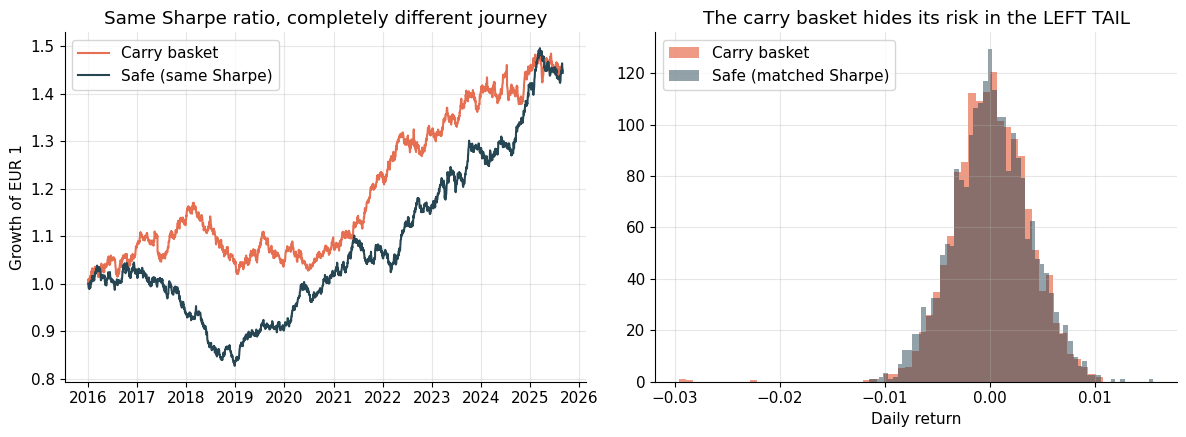

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot((1+basket).cumprod(), label='Carry basket', color='#e76f51')
axes[0].plot((1+safe).cumprod(), label='Safe (same Sharpe)', color='#264653')
axes[0].set_ylabel('Growth of EUR 1')
axes[0].set_title('Same Sharpe ratio, completely different journey')
axes[0].legend()

axes[1].hist(basket, bins=60, alpha=0.7, density=True, color='#e76f51', label='Carry basket')
axes[1].hist(safe, bins=60, alpha=0.5, density=True, color='#264653', label='Safe (matched Sharpe)')
axes[1].set_xlabel('Daily return')
axes[1].set_title('The carry basket hides its risk in the LEFT TAIL')
axes[1].legend()

plt.tight_layout()
plt.show()

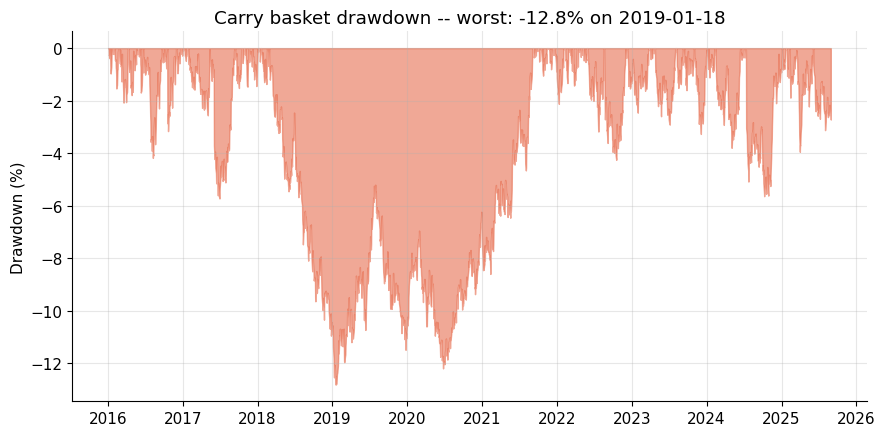

Carry basket: max drawdown -12.8%
Safe strategy: max drawdown -20.8%

Compare this single number to what the skewness/kurtosis columns in stats_table already told you.


In [5]:
cum = (1 + basket).cumprod()
drawdown = cum / cum.cummax() - 1
max_dd = drawdown.min()
max_dd_date = drawdown.idxmin()

fig, ax = plt.subplots()
ax.fill_between(drawdown.index, drawdown.values * 100, 0, color='#e76f51', alpha=0.6)
ax.set_ylabel('Drawdown (%)')
ax.set_title(f'Carry basket drawdown -- worst: {max_dd:.1%} on {max_dd_date.date()}')
plt.tight_layout()
plt.show()

print(f"Carry basket: max drawdown {max_dd:.1%}")
safe_dd = (safe.add(1).cumprod()/safe.add(1).cumprod().cummax()-1).min()
print(f"Safe strategy: max drawdown {safe_dd:.1%}")
print("\nCompare this single number to what the skewness/kurtosis columns in stats_table already told you.")

### Interpreting the result

The `stats_table` comparison is the heart of this notebook: by construction, the two strategies have **exactly** the same annualized return, volatility, and Sharpe ratio, yet the carry basket carries meaningfully negative skewness and heavy excess kurtosis that the Gaussian comparison strategy simply does not have. A risk manager who only checked Sharpe would have rated them identically.

Look carefully at the two max-drawdown numbers as well, and do not assume which one "should" be worse — report what your own run actually shows. Depending on the specific random path drawn, the Gaussian comparison strategy can sometimes show a *deeper* maximum drawdown than the carry basket, simply because ordinary daily volatility, compounded over enough consecutive unlucky days, can chain into a long grinding decline, while the carry basket's risk is concentrated into a handful of sharp, brief episodes. This is a genuinely important, humbling lesson in its own right: even maximum drawdown, a more sophisticated risk metric than Sharpe alone, is still a single number computed on one particular historical path, and it can fail to fully capture *where* a strategy's risk is concentrated. Skewness and kurtosis, which describe the whole shape of the return distribution rather than one worst-case episode, are what actually reveals the carry trade's distinctive risk here — which is exactly why Section 3.3 introduced them before we ever looked at a single equity curve.

## 6. Limitations and pitfalls

- **Real FX trading has additional frictions our simulation ignores** — most importantly, bid-ask spreads that can widen dramatically at precisely the moment a crash makes you want to exit, meaning realized crash losses in practice are often worse than the "clean" price move alone would suggest.
- **Leverage is central to real carry trades** — the interest-rate differentials involved are often small in absolute terms, so carry strategies are frequently levered up to reach a meaningful return, which scales both the steady gains and the crash losses, and introduces margin-call and funding risk we have not modeled at all.
- **Our crash mechanism is a deliberate simplification.** Real crashes have complex, varied triggers and contagion channels (central bank interventions, forced deleveraging cascades, liquidity spirals) that a single shared Bernoulli trigger does not capture.
- **Tail risk is hard to estimate precisely from history, because tail events are — by definition — rare.** A backtest covering "only" ten or twenty years may simply not contain the worst plausible crash, which is a deep, structural limitation of backtesting this class of strategy at all, not just a data-availability inconvenience (Module 6 returns to this theme directly).
- **Carry exists in other asset classes too** (commodity roll yield, the bond term premium), via related but distinct mechanisms not explored in this FX-focused treatment.

## 7. Exercises

**1. Sharpe ratio alone is not enough (warm-up).**
Using `stats_table`, confirm numerically that the two strategies' Sharpe ratios are close, while their skewness and kurtosis are not. Then compute each strategy's **Sortino ratio** (like Sharpe, but using only downside deviation — the standard deviation of *negative* returns only — in the denominator instead of total volatility). Does the Sortino ratio tell a more consistent story with the skewness numbers than Sharpe did?

**2. Rare but severe vs. frequent but mild.**
Create two modified versions of the crash mechanism: one with `p_crash` cut in half but `crash_severity` doubled (rarer, more severe crashes), and one with `p_crash` doubled but `crash_severity` halved (more frequent, milder crashes) — try to keep the *average* return roughly similar across both versions by adjusting `uip_offset_fraction` if needed. Compare Sharpe ratio, skewness, and maximum drawdown across the two versions. Which combination does a Sharpe ratio "hide" more effectively?

**3. A volatility-aware overlay.**
Implement a simple risk-off overlay: compute a rolling 20-day realized volatility of the `basket` series, and scale down (e.g., halve) the strategy's exposure whenever that rolling volatility exceeds some multiple (e.g., 1.5x) of its own longer-run (e.g., 120-day) average. Backtest this overlay version against the original constant-exposure basket. Quantify the trade-off directly: how much average annual return is given up in normal times, versus how much the maximum drawdown improves?